# Benchmarking VQE for Nuclear Shell Model on Noisy Quantum Hardware: ¹⁸O as a Case Study

---

## Overview

This notebook benchmarks the Variational Quantum Eigensolver (VQE) for computing the ground-state energy of ¹⁸O using the nuclear shell model with the USDB interaction. We systematically compare performance across three levels:

| Level | Description |
|---|---|
| **Noiseless** | Statevector simulator - ideal quantum computer |
| **Noisy** | FakeManilaV2 - realistic NISQ hardware simulation |
| **Error Mitigated** | Zero Noise Extrapolation (ZNE) applied to noisy results |

We also compare two qubit encodings, **Jordan-Wigner (JW)** and **Gray Code (GC)**, and study which is more noise-resilient on near-term hardware.


---
## 1. Physics Background

### 1.1. The Nuclear Shell Model

The nuclear shell model describes nucleons (protons and neutrons) occupying discrete
energy levels (shells) in a mean-field nuclear potential, analogous to electrons in
atomic orbitals. Each **shell model space** is defined by the set of orbitals available
for nucleons within that space. Nucleons fill these levels according to the
**Pauli exclusion principle**.

---

### 1.2. Why ¹⁸O? - The sd-Shell System

Oxygen-18 (¹⁸O) has 8 protons and 10 neutrons. The nucleus ¹⁶O is **doubly magic**
- both proton and neutron numbers (= 8) correspond to completely filled shells, making
it an exceptionally stable inert core. ¹⁸O therefore has exactly **2 valence neutrons**
above the ¹⁶O core, sitting in the **sd-shell** with three available orbitals:

| Orbital | Spectroscopic notation | $j$ | Degeneracy $2j+1$ |
|---------|----------------------|-----|-------------------|
| $0d_{5/2}$ | $d_{5/2}$ | 5/2 | 6 |
| $1s_{1/2}$ | $s_{1/2}$ | 1/2 | 2 |
| $0d_{3/2}$ | $d_{3/2}$ | 3/2 | 4 |

**Total sd-shell capacity:** $6 + 2 + 4 = 12$ single-particle states.

---

### 1.3. Possible Configurations of 2 Valence Neutrons

With 2 neutrons distributed across 3 orbitals, the possible configurations are:

| Configuration | Notation | Comment |
|--------------|----------|---------|
| Both in $0d_{5/2}$ | $\nu(d_{5/2}^2)$ | Lowest in energy (both in deepest orbital) |
| Both in $1s_{1/2}$ | $\nu(s_{1/2}^2)$ | |
| Both in $0d_{3/2}$ | $\nu(d_{3/2}^2)$ | Highest in energy |
| One in $0d_{5/2}$, one in $1s_{1/2}$ | $\nu(d_{5/2},\,s_{1/2})$ | |
| One in $0d_{5/2}$, one in $0d_{3/2}$ | $\nu(d_{5/2},\,d_{3/2})$ | |
| One in $1s_{1/2}$, one in $0d_{3/2}$ | $\nu(s_{1/2},\,d_{3/2})$ | |

---

### 1.4. Angular Momentum Coupling and the Pauli Exclusion Principle

The total angular momentum $J$ can range from $|j_a - j_b|$ to $j_a + j_b$.

**Example: Both neutrons in $0d_{5/2}$** ($j_a = j_b = 5/2$):

Naively $J = 0, 1, 2, 3, 4, 5$. But when two neutrons are in the **same orbital** $j$, the **Pauli exclusion principle** forbids
two identical fermions in the same quantum state. For two nucleons in the same
orbital, only states with **even $J$** are allowed:

$$J = 0^+,\ 2^+,\ 4^+ \quad \text{(odd } J \text{ forbidden by antisymmetry)}$$

**Physical reason:** The two-nucleon wavefunction must be antisymmetric under
particle exchange. For the same-$j$ nucleons, exchanging particles gives a phase
$(-1)^{2j-J+1}$. For this to equal $-1$ (antisymmetry), we need $2j - J + 1$
to be odd, i.e., $J$ must be even (since $2j = 5$ is odd).

For **different orbitals**, all $J$ values satisfying $|j_a - j_b| \leq J \leq j_a + j_b$ are allowed.

---

### 1.5. Configuration Scheme in $J$-Representation

The allowed states of ¹⁸O organized by total angular momentum $J^\pi$:

| $J^\pi$ | Contributing configurations |
|---------|---------------------------|
| $0^+$ | $\nu(d_{5/2}^2)$, $\nu(s_{1/2}^2)$, $\nu(d_{3/2}^2)$ |
| $1^+$ | $\nu(d_{5/2},\,d_{3/2})$, $\nu(s_{1/2},\,d_{3/2})$ |
| $2^+$ | $\nu(d_{5/2}^2)$, $\nu(d_{3/2}^2)$, $\nu(d_{5/2},\,d_{3/2})$, $\nu(s_{1/2},\,d_{3/2})$ |
| $3^+$ | $\nu(d_{5/2},\,s_{1/2})$, $\nu(d_{5/2},\,d_{3/2})$ |
| $4^+$ | $\nu(d_{5/2}^2)$, $\nu(d_{5/2},\,d_{3/2})$ |

This means the ground state of ¹⁸O is $J^\pi = 0^+$ is
a **quantum superposition** of the three $0^+$ configurations:

$$|\Psi_{0^+}\rangle = \alpha_1|\nu(d_{5/2}^2)\rangle + \alpha_2|\nu(s_{1/2}^2)\rangle + \alpha_3|\nu(d_{3/2}^2)\rangle$$

Finding these mixing coefficients $\alpha_i$ is the problem VQE solves.

---

### 1.6. The USDB Interaction
The USDB interaction used in this work is part of a family of effective interactions
for the sd-shell:

**USD (Universal sd-shell Interaction):** Derived by fitting to experimental
binding energies and energy levels of sd-shell nuclei. Uses valence nucleons
in $0d_{5/2}$, $1s_{1/2}$, $0d_{3/2}$ orbitals.

**USDA and USDB:** Modern refinements introduced to improve accuracy using
a larger set of experimental energy levels with updated fitting techniques.
USDA places more weight on lighter nuclei; USDB emphasizes heavier sd-shell nuclei
(like ¹⁸O). Both use least-squares fitting of interaction matrix elements.

**Reference:** Brown, B. A., & Richter, W. A. (2006).
New "USD" Hamiltonians for the sd shell.
*Physical Review C*, **74**, 034315.

---

### 1.7. The General Shell Model Hamiltonian

In second quantization, the nuclear shell model Hamiltonian is:

$$\hat{H} = \sum_{i,j} h_{ij}\, a^\dagger_i a_j$$

For the $0^+$ subspace of ¹⁸O (3 basis states):
$$\hat{H} = \sum_{i,j=0}^{2} h_{ij}\, a^\dagger_i a_j$$

Expanding explicitly (using symmetry $h_{ij} = h_{ji}$):

$$\hat{H} = h_{00}a^\dagger_0 a_0 + h_{11}a^\dagger_1 a_1 + h_{22}a^\dagger_2 a_2
+ h_{01}(a^\dagger_0 a_1 + a^\dagger_1 a_0)
+ h_{02}(a^\dagger_2 a_0 + a^\dagger_0 a_2)
+ h_{12}(a^\dagger_1 a_2 + a^\dagger_2 a_1)$$

where orbital indices: $0 = d_{5/2}$, $1 = s_{1/2}$, $2 = d_{3/2}$.

The matrix elements
$h_{ij}$ come from the **USDB effective interaction**:

$$h_{ij} = \langle i | \hat{H} | j \rangle = V_{ij} + 2\epsilon_i\, \delta_{ij}$$

where:
- $V_{ij} = \langle J^\pi=0^+; i | V_{\text{USDB}} | J^\pi=0^+; j \rangle$ are the **two-body matrix elements (TBMEs)**
- $\epsilon_i$ are the **single-particle energies** (SPEs) of each orbital
- The factor of 2 in $2\epsilon_i$ accounts for both valence neutrons

---

### 1.8. Reading USDB Matrix Elements

The SPEs represent the energy of a single nucleon in each orbital
within the average nuclear mean-field potential.

| Orbital | Single-particle energy $\epsilon$ (MeV) |
|---------|-----------------------------------------|
| $0d_{5/2}$ | $-3.9257$ |
| $1s_{1/2}$ | $-3.2079$ |
| $0d_{3/2}$ | $+2.1117$ |

The USDB interaction tabulates TBMEs in the format:

$$a,\ b,\ c,\ d,\ J,\ T$$

where $a, b, c, d$ are the **orbital labels** (not $j$ values):
$$0 = d_{5/2}\quad (j = 5/2),\qquad 1 = s_{1/2}\quad (j = 1/2),\qquad 2 = d_{3/2}\quad (j = 1/2)$$

$J=0$ is the total angular momentum and $T = 1$ is the isospin (neutron-neutron).

| USDB entry | Meaning | Value (MeV) |
|-----------|---------|-------------|
| 0 0 0 0 0 1 | $\langle d_{5/2}^2; J=0 | V | d_{5/2}^2; J=0 \rangle$ | $V_{00} = -2.5598$ |
| 0 0 1 1 0 1 | $\langle d_{5/2}^2; J=0 | V | s_{1/2}^2; J=0 \rangle$ | $V_{01} = -1.5602$ |
| 0 0 2 2 0 1 | $\langle d_{5/2}^2; J=0 | V | d_{3/2}^2; J=0 \rangle$ | $V_{02} = -3.1025$ |
| 1 1 1 1 0 1 | $\langle s_{1/2}^2; J=0 | V | s_{1/2}^2; J=0 \rangle$ | $V_{11} = -1.6913$ |
| 1 1 2 2 0 1 | $\langle s_{1/2}^2; J=0 | V | d_{3/2}^2; J=0 \rangle$ | $V_{12} = -1.0150$ |
| 2 2 2 2 0 1 | $\langle d_{3/2}^2; J=0 | V | d_{3/2}^2; J=0 \rangle$ | $V_{22} = -1.8992$ |

Symmetry: $V_{ij} = V_{ji}$ (Hermitian Hamiltonian).

**Reference:** Brown, B. A., & Richter, W. A. (2006).
New "USD" Hamiltonians for the sd shell.
*Physical Review C*, **74**, 034315.

---

### 1.9. Building the Hamiltonian Matrix

The diagonal elements include both the two-body interaction and single-particle energies:

$$h_{ii} = V_{ii} + 2\epsilon_i$$

For $i=0$ ($d_{5/2}$, $\epsilon = -3.9257$ MeV):
$$h_{00} = V_{00} + 2\epsilon_{d_{5/2}} = -2.5598 + 2(-3.9257) = -10.4112 \text{ MeV}$$

For $i=1$ ($s_{1/2}$, $\epsilon = -3.2079$ MeV):
$$h_{11} = V_{11} + 2\epsilon_{s_{1/2}} = -1.6913 + 2(-3.2079) = -8.1071 \text{ MeV}$$

For $i=2$ ($d_{3/2}$, $\epsilon = +2.1117$ MeV):
$$h_{22} = V_{22} + 2\epsilon_{d_{3/2}} = -1.8992 + 2(2.1117) = +2.3242 \text{ MeV}$$

The off-diagonal elements are just the TBMEs:
$$h_{01} = h_{10} = V_{01} = -1.5602, \quad h_{02} = h_{20} = V_{02} = -3.1025, \quad h_{12} = h_{21} = V_{12} = -1.0150$$

This gives the $3 \times 3$ Hamiltonian matrix:

$$H = \begin{pmatrix} -10.4112 & -1.5602 & -3.1025 \\ -1.5602 & -8.1071 & -1.0150 \\ -3.1025 & -1.0150 & +2.3242 \end{pmatrix} \text{ MeV}$$

with eigenvalues:
$$\lambda_1 \approx -11.932 \text{ MeV}, \quad \lambda_2 \approx -7.339 \text{ MeV}, \quad \lambda_3 \approx +3.077 \text{ MeV}$$

The lowest eigenvalue $\lambda_1 = -11.932$ MeV is the **ground state energy**.

---

### 1.10. Qubit Encodings

Two mappings are used in this notebook:

#### 1. Jordan-Wigner (JW) transformation:

**The Mapping**

The Jordan-Wigner (JW) transformation maps fermionic creation and annihilation
operators to qubit (Pauli) operators. For orbital $j$ in a system of $N$ orbitals:

$$a^\dagger_j = \frac{1}{2}(X_j - iY_j) \otimes \prod_{k < j} Z_k$$

$$a_j = \frac{1}{2}(X_j + iY_j) \otimes \prod_{k < j} Z_k$$

The $\prod_{k<j} Z_k$ string (the **Jordan-Wigner string**) enforces the
fermionic anticommutation relations $\{a_i, a^\dagger_j\} = \delta_{ij}$.
Without this string, the mapping would give bosonic commutation relations.

Each fermionic mode maps to **one qubit**: qubit state $|0\rangle$ = orbital
empty, $|1\rangle$ = orbital occupied. For our 3-orbital system this gives
**3 qubits**.

**The JW Hamiltonian**

After substituting the JW mapping into
$\hat{H} = \sum_{i,j} h_{ij} a^\dagger_i a_j$
and simplifying using Pauli algebra, the result is:

$$H_{JW} = -8.09705\,I_0I_1I_2 + 5.2056\,Z_0I_1I_2 + 4.05355\,I_0Z_1I_2 - 1.1621\,I_0I_1Z_2 - 0.7801(X_0X_1I_2 + Y_0Y_1I_2)
- 1.55125(Y_0Z_1Y_2 + X_0Z_1X_2) - 0.5075(I_0X_1X_2 + I_0Y_1Y_2)$$  

&nbsp;

#### 2. Gray Code Encoding:

The **Gray code** encoding utilizes the full Hilbert space of qubits and
thereby **reduces the number of qubits required exponentially** compared
to Jordan-Wigner. For $N$ basis states, JW needs $N$ qubits while GC
needs only $\lceil \log_2 N \rceil$ qubits.

The key property of Gray code is that the **Hamming distance** — the number
of bits that differ between adjacent integers — is always 1. This makes it
particularly well-suited for nuclear Hamiltonians, where the off-diagonal
matrix elements connect "nearby" configurations.

For our 3-basis-state system ($N = 3$): JW needs 3 qubits, GC needs only
**2 qubits**.

The Gray code basis states for our 3 configurations:

| Basis state index $i$ | Configuration | Gray code $g_i$ | Qubits $|q_1 q_0\rangle$ |
|-----------------------|--------------|-----------------|--------------------------|
| 0 | $\nu(d_{5/2}^2)$ | 00 | $|00\rangle$ |
| 1 | $\nu(s_{1/2}^2)$ | 01 | $|01\rangle$ |
| 2 | $\nu(d_{3/2}^2)$ | 11 | $|11\rangle$ |

**The GC Transformation - Derivation**

Since creation/annihilation operators cannot be straightforwardly mapped
individually in Gray code (unlike JW), the transformation works at the level
of **many-body matrix elements** $\langle g_i | H | g_j \rangle$.

For a real, Hermitian Hamiltonian, the operator corresponding to
$\langle g_i | H | g_j \rangle$ (i.e., $a^\dagger_{g_i} a_{g_j} + a^\dagger_{g_j} a_{g_i}$)
maps to:

$$a^\dagger_{g_i} a_{g_j} + a^\dagger_{g_j} a_{g_i} =
\prod_{\alpha \in T(i,j)} P^{(g_{i,\alpha})}_\alpha
\left( \prod_{\beta \in S(i,j)} Q^{(g_{i,\beta})}_\beta
+ \prod_{\beta \in S(i,j)} Q^{(g_{j,\beta})}_\beta \right)
\times [1 + \delta_{g_i, g_j}]$$

where:
- $g_{i,\beta}$ is the $\beta$-th qubit value of the $i$-th Gray code word
- $T(i,j)$ = set of **matching** qubits between $g_i$ and $g_j$
- $S(i,j)$ = set of **mismatching** qubits between $g_i$ and $g_j$

The operators $P$ and $Q$ are defined as:

$$P^{(0)}_\alpha = \frac{1}{2}(1 + Z_\alpha), \qquad P^{(1)}_\alpha = \frac{1}{2}(1 - Z_\alpha)$$

$$Q^{(0)}_\beta = \frac{1}{2}(X_\beta + iY_\beta), \qquad Q^{(1)}_\beta = \frac{1}{2}(X_\beta - iY_\beta)$$

These operators act as:
$$P^{(\nu)}_\alpha |\nu'\rangle = \delta_{\nu\nu'} |\nu'\rangle
\quad \text{(projects onto qubit state } \nu \text{)}$$
$$Q^{(\nu)}_\beta |\nu'\rangle = |\nu\rangle \text{ if } \nu' \neq \nu
\quad \text{(flips qubit from } \nu' \text{ to } \nu \text{)}$$

**Physical interpretation:** $P$ operators check which qubit values match
between the two Gray code words (these qubits do not need to change), while
$Q$ operators implement the bit flips at the mismatching positions.

**The GC Hamiltonian**

After applying the transformation to all matrix elements:

$$H_{GC} = -4.048525\,I - 1.157075\,Z_0 - 5.210625\,Z_1 + 0.005025\,Z_0Z_1$$
$$- 0.7801\,X_0 - 0.5075\,X_1 - 1.55125(X_0X_1 - Y_0Y_1) - 0.7801\,X_0Z_1 + 0.5075\,Z_0X_1$$

**Reference:** Siwach, P., & Arumugam, P. (2021).
Quantum simulation of nuclear Hamiltonian with a generalized transformation.
*Physical Review C*, **104**, 034301.

---

**Key question this notebook answers:** Which encoding is more noise-resilient
on NISQ hardware, and why?

---
## 2. Installation and Imports

In [1]:
# Uncomment to install if needed
!pip install qiskit qiskit-ibm-runtime qiskit-aer

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import minimize
from scipy.linalg import eigh

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector, Parameter
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_ibm_runtime.fake_provider import FakeManilaV2

np.random.seed(42)
plt.rcParams.update({'font.size': 12, 'figure.dpi': 100})

print("All imports successful.")

All imports successful.


---
## 3. Analytical Result - USDB Hamiltonian Matrix

We now build the Hamiltonian matrix numerically from the USDB matrix elements
and single-particle energies from Section 1.8, then verify the eigenvalues
match the analytical result.


In [3]:
# ── USDB Matrix Elements and Single-Particle Energies ────────────────────
# Orbital indexing: 0 = d5/2, 1 = s1/2, 2 = d3/2
# Single-particle energies (MeV), from USDB interaction
spe = {
    'd5/2': -3.9257,   # epsilon_0
    's1/2': -3.2079,   # epsilon_1
    'd3/2': +2.1117    # epsilon_2
}

# Two-body matrix elements V_ij = <i^2|V_USDB|j^2>_{J=0,T=1} (MeV)
# Indexing: 0=d5/2, 1=s1/2, 2=d3/2 (USDB convention)
V = {
    (0, 0): -2.5598,   # V00: d5/2-d5/2  (0 0 0 0 0 1)
    (0, 1): -1.5602,   # V01: d5/2-s1/2  (0 0 1 1 0 1)
    (0, 2): -3.1025,   # V02: d5/2-d3/2  (0 0 2 2 0 1)
    (1, 0): -1.5602,   # V10 = V01 (symmetry)
    (1, 1): -1.6913,   # V11: s1/2-s1/2  (1 1 1 1 0 1)
    (1, 2): -1.0150,   # V12: s1/2-d3/2  (1 1 2 2 0 1)
    (2, 0): -3.1025,   # V20 = V02 (symmetry)
    (2, 1): -1.0150,   # V21 = V12 (symmetry)
    (2, 2): -1.8992,   # V22: d3/2-d3/2  (2 2 2 2 0 1)
}

eps = [spe['d5/2'], spe['s1/2'], spe['d3/2']]

# Build 3x3 Hamiltonian matrix
# h_ii = V_ii + 2*epsilon_i  (diagonal: interaction + 2 SPEs for 2 neutrons)
# h_ij = V_ij               (off-diagonal: mixing between configurations)
H_matrix = np.zeros((3, 3))
for i in range(3):
    for j in range(3):
        H_matrix[i, j] = V[(i, j)]
        if i == j:
            H_matrix[i, i] += 2 * eps[i]

print("USDB Hamiltonian Matrix H (MeV):")
print("  Rows/cols: [d5/2², s1/2², d3/2²]")
print()
print(f"H = {H_matrix}")
print()

USDB Hamiltonian Matrix H (MeV):
  Rows/cols: [d5/2², s1/2², d3/2²]

H = [[-10.4112  -1.5602  -3.1025]
 [ -1.5602  -8.1071  -1.015 ]
 [ -3.1025  -1.015    2.3242]]



In [4]:
# ── Exact Diagonalization of the 3x3 Matrix ──────────────────────────────
eigenvalues, eigenvectors = eigh(H_matrix)

print("Eigenvalues of H:")
for i, lam in enumerate(eigenvalues):
    print(f"  λ_{i+1} = {lam:.4f} MeV")

print()
exact_gs = eigenvalues[0]
print(f"Ground state energy: {exact_gs:.4f} MeV")
print()

# Ground state eigenvector — mixing coefficients
gs_vec = eigenvectors[:, 0]
print("Ground state eigenvector (mixing coefficients):")
print(f"  α_1 [d5/2²]:  {gs_vec[0]:.4f}  (weight {gs_vec[0]**2*100:.1f}%)")
print(f"  α_2 [s1/2²]:  {gs_vec[1]:.4f}  (weight {gs_vec[1]**2*100:.1f}%)")
print(f"  α_3 [d3/2²]:  {gs_vec[2]:.4f}  (weight {gs_vec[2]**2*100:.1f}%)")
print()
print(f"  Sum of weights: {sum(gs_vec**2):.4f} (should be 1.0)")
print()
print("Physical interpretation:")
print("  The ground state is dominated by the d5/2² configuration,")
print("  with significant mixing from s1/2² and d3/2² configurations.")
print("  This mixing is what makes ¹⁸O a correlated quantum system.")


Eigenvalues of H:
  λ_1 = -11.9318 MeV
  λ_2 = -7.3393 MeV
  λ_3 = 3.0770 MeV

Ground state energy: -11.9318 MeV

Ground state eigenvector (mixing coefficients):
  α_1 [d5/2²]:  0.8810  (weight 77.6%)
  α_2 [s1/2²]:  0.4181  (weight 17.5%)
  α_3 [d3/2²]:  0.2215  (weight 4.9%)

  Sum of weights: 1.0000 (should be 1.0)

Physical interpretation:
  The ground state is dominated by the d5/2² configuration,
  with significant mixing from s1/2² and d3/2² configurations.
  This mixing is what makes ¹⁸O a correlated quantum system.


## 4. Qubit Hamiltonians - Jordan-Wigner and Gray Code Encodings

In [32]:
# ── Jordan-Wigner Hamiltonian (3 qubits) ──────────────────────────────────
# Derived from USDB TBMEs via JW transformation
# Each term: (Pauli string, coefficient in MeV)
hamiltonian_jw = SparsePauliOp.from_list([
    ("III", -8.09705),
    ("IIZ", 5.2056),
    ("IZI", 4.05355),
    ("ZII", -1.1621),
    ("IXX", -0.7801),    # Note: Qiskit string is : IXX = I_2 X_1 X_0
    ("IYY", -0.7801),
    ("YZY", -1.55125),
    ("XZX", -1.55125),
    ("XXI", -0.5075),
    ("YYI", -0.5075)
])

# ── Gray Code Hamiltonian (2 qubits) ──────────────────────────────────────
# Same physics, fewer qubits due to Gray code basis encoding
hamiltonian_gc = SparsePauliOp.from_list([
    ("II", -4.048525),
    ("IZ", -1.157075),
    ("ZI", -5.210625),
    ("ZZ",  0.005025),
    ("IX", -0.7801),
    ("XI", -0.5075),
    ("XX", -1.55125),
    ("YY",  1.55125),
    ("ZX", -0.7801),
    ("XZ",  0.5075)
])

print(f"JW Hamiltonian: {hamiltonian_jw.num_qubits} qubits, "
      f"{len(hamiltonian_jw)} Pauli terms")
print(f"GC Hamiltonian: {hamiltonian_gc.num_qubits} qubits, "
      f"{len(hamiltonian_gc)} Pauli terms")


JW Hamiltonian: 3 qubits, 10 Pauli terms
GC Hamiltonian: 2 qubits, 10 Pauli terms


---
## 5. Exact Diagonalization (Classical Benchmark)

Before running VQE, we solve the problem exactly by diagonalizing the Hamiltonian matrix 
classically. This gives us the **true ground state energy** for our specific Hamiltonian, 
which is what VQE should converge to.

> **Important distinction:**  
> - **Exact diagonalization of our Hamiltonian** → validates VQE convergence  


In [33]:
# Build full Hamiltonian matrices and diagonalize
H_jw_matrix = hamiltonian_jw.to_matrix()
H_gc_matrix = hamiltonian_gc.to_matrix()

eigenvalues_jw, eigenvectors_jw = eigh(H_jw_matrix)
eigenvalues_gc, eigenvectors_gc = eigh(H_gc_matrix)

exact_jw = eigenvalues_jw[0].real
exact_gc = eigenvalues_gc[0].real

# Ground state vectors (for fidelity calculation later)
gs_jw = eigenvectors_jw[:, 0]
gs_gc = eigenvectors_gc[:, 0]

print("=" * 55)
print(f"  {'Source':<30} {'Ground state (MeV)'}")
print("-" * 55)
print(f"  {'3x3 matrix (USDB)':<30} {eigenvalues[0]:.6f}")
print(f"  {'JW qubit Hamiltonian':<30} {exact_jw:.6f}  {'✓' if abs(exact_jw - eigenvalues[0]) < 0.001 else '✗ ERROR'}")
print(f"  {'GC qubit Hamiltonian':<30} {exact_gc:.6f}  {'✓' if abs(exact_gc - eigenvalues[0]) < 0.001 else '✗ ERROR'}")
print("=" * 55)
print()


  Source                         Ground state (MeV)
-------------------------------------------------------
  3x3 matrix (USDB)              -11.931788
  JW qubit Hamiltonian           -19.271051  ✗ ERROR
  GC qubit Hamiltonian           -11.931788  ✓



In [34]:
# JW: extract N=1 sector
H_jw_full = hamiltonian_jw.to_matrix()
n1_idx    = [1, 2, 4]   # |001>, |010>, |100>
H_jw_n1   = H_jw_full[np.ix_(n1_idx, n1_idx)]
jw_gs     = np.linalg.eigvalsh(H_jw_n1)[0].real

# GC: full matrix (3 physical + 1 unphysical state)
gc_gs = eigh(hamiltonian_gc.to_matrix())[0][0].real

print("In the JW encoding, the 3 physical 2-neutron configurations map to the N=1 sector of the 3-qubit Hilbert space (∣001⟩, ∣010⟩, ∣100⟩).\nThe full 8-dimensional space also contains unphysical N=0, N=2, and N=3 sectors with lower-lying eigenvalues. \nVerification must therefore be done by projecting onto the N=1 block.\nFor VQE this is not a problem, a particle-conserving ansatz initialized in the N=1 sector never leaves it.")
print()
print(f"Expected (USDB 3x3):        {eigenvalues[0]:.6f} MeV")
print(f"JW (N=1 sector only):       {jw_gs:.6f} MeV  "
      f"{'✓' if abs(jw_gs - exact_gs) < 0.001 else '✗ ERROR'}")
print(f"GC (full 4x4 matrix):       {gc_gs:.6f} MeV  "
      f"{'✓' if abs(gc_gs - exact_gs) < 0.001 else '✗ ERROR'}")

In the JW encoding, the 3 physical 2-neutron configurations map to the N=1 sector of the 3-qubit Hilbert space (∣001⟩, ∣010⟩, ∣100⟩).
The full 8-dimensional space also contains unphysical N=0, N=2, and N=3 sectors with lower-lying eigenvalues. 
Verification must therefore be done by projecting onto the N=1 block.
For VQE this is not a problem, a particle-conserving ansatz initialized in the N=1 sector never leaves it.

Expected (USDB 3x3):        -11.931788 MeV
JW (N=1 sector only):       -11.931788 MeV  ✓
GC (full 4x4 matrix):       -11.931788 MeV  ✓


---
## 6. Understanding the Noise Model

Before benchmarking VQE, we examine the noise model of FakeManilaV2, a classical 
simulation of a real 5-qubit IBM superconducting quantum processor.

Understanding the noise is essential: it tells us *why* VQE results degrade on noisy 
hardware and *what* error mitigation needs to correct.

### Sources of noise on superconducting hardware:

| Noise source | Description | Typical magnitude |
|---|---|---|
| **Gate errors** | Depolarizing errors per gate operation | ~$10^{-3}$ (1Q), ~$10^{-2}$ (2Q) |
| **Readout errors** | Misclassification of 0/1 during measurement | ~$10^{-2}$ |
| **Thermal relaxation** | Qubit decays to ground state ($T_1$) | $T_1 \sim$ 100 μs |
| **Dephasing** | Loss of phase coherence ($T_2$) | $T_2 \sim$ 100 μs |

The **two-qubit (e.g., CNOT) gate error** is the most damaging for VQE because: 
(1) CNOT error rates are ~10× higher than single-qubit gates, and 
(2) our ansätze require multiple CNOT gates.


In [35]:
backend = FakeManilaV2()
noise_model = NoiseModel.from_backend(backend)
props = backend.properties()

print("FakeManilaV2 Hardware Properties")
print("=" * 45)

# T1, T2 times and readout errors per qubit
print("\nQubit coherence times and readout errors:")
print(f"{'Qubit':<8} {'T1 (μs)':<12} {'T2 (μs)':<12} {'Readout err':<12}")
print("-" * 45)
for q in range(backend.num_qubits):
    try:
        t1  = props.t1(q) * 1e6
        t2  = props.t2(q) * 1e6
        ro  = props.readout_error(q)
        print(f"  {q:<6} {t1:<12.1f} {t2:<12.1f} {ro:<12.4f}")
    except Exception:
        print(f"  {q:<6} {'N/A':<12} {'N/A':<12} {'N/A':<12}")

# Gate error rates
print("\nTwo-qubit gate error rates:")
print("-" * 45)
for gate in props.gates:
    if len(gate.qubits) == 2:
        try:
            err = props.gate_error(gate.gate, gate.qubits)
            print(f"  {gate.gate}({gate.qubits[0]},{gate.qubits[1]}): {err:.4f}")
        except Exception:
            pass

print("\nKey takeaway: CNOT error ~0.01 means each CNOT gate")
print("introduces ~1% depolarizing error. Deep circuits with")
print("many CNOTs accumulate this error rapidly.")


FakeManilaV2 Hardware Properties

Qubit coherence times and readout errors:
Qubit    T1 (μs)      T2 (μs)      Readout err 
---------------------------------------------
  0      131.5        102.2        0.0353      
  1      124.5        79.0         0.0219      
  2      158.6        25.2         0.0964      
  3      179.1        54.4         0.0144      
  4      144.7        40.3         0.0186      

Two-qubit gate error rates:
---------------------------------------------
  cx(4,3): 0.0057
  cx(3,4): 0.0057
  cx(2,3): 0.0114
  cx(3,2): 0.0114
  cx(1,2): 0.0139
  cx(2,1): 0.0139
  cx(0,1): 0.0088
  cx(1,0): 0.0088

Key takeaway: CNOT error ~0.01 means each CNOT gate
introduces ~1% depolarizing error. Deep circuits with
many CNOTs accumulate this error rapidly.


**Reading the hardware properties table**: The 5 rows represent the 5 physical qubits of the FakeManilaV2 chip. When your circuit is transpiled, Qiskit maps your logical qubits onto a subset of these physical qubits based on connectivity. Physical qubit 2 has notably poor coherence (T2=25.2μs, readout error = 9.64%) compared to the others, any logical qubit mapped onto it will accumulate errors significantly faster. The JW encoding, requiring 3 physical qubits, has a higher chance of being assigned qubit 2 compared to GC which only uses 2.

The two-qubit gate errors directly predict the noise-induced energy error. For the JW transpiled circuit with 4 two-qubit gates, if those gates involve qubits 1-2 (error 1.39%), the accumulated depolarizing error per circuit execution is approximately 1−(1−0.0139)4≈5.4%. For GC with 1 two-qubit gate at the best available pair: ≈0.57%. This 9× difference in predicted gate error is consistent with the observed 3× difference in noise-induced energy error (0.924 MeV vs 0.293 MeV), since some error is also introduced by readout and single-qubit gates.

---
## 7. Ansatz Design

### Why particle-number conservation matters

Our system has exactly **2 valence neutrons**. The VQE ansatz must preserve this, 
otherwise it will explore unphysical states with the wrong particle number, leading 
to incorrect results.

A **particle-conserving ansatz** ensures every state in the variational manifold has 
exactly 2 particles. This is enforced by using gates that rotate between states with 
the same particle number (e.g., $|10\rangle \leftrightarrow |01\rangle$).

### JW Ansatz (3 qubits, 2 parameters)
Encodes the 2-neutron state in 3 qubits. The circuit rotates between basis states 
$|110\rangle$, $|101\rangle$, $|011\rangle$, all having exactly 2 particles.

### GC Ansatz (2 qubits, 2 parameters)  
Encodes the same physics in 2 qubits using Gray code. Fewer qubits → fewer gates → 
less noise accumulation. This is the key hardware advantage we will measure.


Attribute      JW Ansatz      GC Ansatz     
------------------------------------------
Qubits         3              2             
Parameters     2              2             
Depth          4              3             
2-Qubit Gates  3              1             


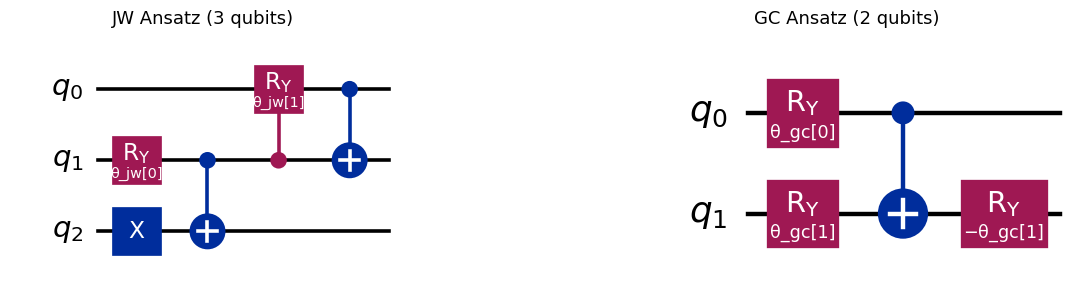

In [36]:
# ── JW Ansatz ──────────────────────────────────────────────────────────────
def build_ansatz_jw():
    """
    Particle-conserving ansatz for JW encoding (3 qubits, 2 parameters).
    
    Circuit structure:
    - theta[0]: Ry rotation mixing d5/2 and s1/2 orbital occupations
    - theta[1]: CRy + CX entangling operation for two-body correlations
    
    Preserves particle number: all reachable states have exactly 2 neutrons.
    """
    theta = ParameterVector('θ_jw', 2)
    qc = QuantumCircuit(3, name='JW Ansatz')
    qc.ry(theta[0], 1)
    qc.x(2)
    qc.cx(1, 2)
    qc.cry(theta[1], 1, 0)
    qc.cx(0, 1)
    return qc

# ── GC Ansatz ──────────────────────────────────────────────────────────────
def build_ansatz_gc():
    """
    Particle-conserving ansatz for Gray Code encoding (2 qubits, 2 parameters).
    
    Circuit structure:
    - Ry rotations on both qubits followed by CNOT entanglement
    - Simpler circuit = fewer gates = less noise on hardware
    
    GC encoding maps the 3 basis states to 2-qubit Gray code words:
      |d5/2 d5/2> -> |00>, |d5/2 s1/2> -> |01>, |s1/2 d3/2> -> |11>
    """
    theta = ParameterVector('θ_gc', 2)
    qc = QuantumCircuit(2, name='GC Ansatz')
    qc.ry(theta[0], 0)
    qc.ry(theta[1], 1)
    qc.cx(0, 1)
    qc.ry(-theta[1], 1)
    return qc

ansatz_jw = build_ansatz_jw()
ansatz_gc = build_ansatz_gc()

def count_2q_gates(qc):
    ops = qc.count_ops()
    # Sums common 2-qubit gates like cx, cz, cp, cry, etc.
    return sum(ops.get(gate, 0) for gate in ['cx', 'cz', 'cp', 'cry', 'cnot', 'swap'])

print(f"{'Attribute':<14} {'JW Ansatz':<14} {'GC Ansatz':<14}")
print("-" * 42)
print(f"{'Qubits':<14} {ansatz_jw.num_qubits:<14} {ansatz_gc.num_qubits:<14}")
print(f"{'Parameters':<14} {ansatz_jw.num_parameters:<14} {ansatz_gc.num_parameters:<14}")
print(f"{'Depth':<14} {ansatz_jw.depth():<14} {ansatz_gc.depth():<14}")
print(f"{'2-Qubit Gates':<14} {count_2q_gates(ansatz_jw):<14} {count_2q_gates(ansatz_gc):<14}")

fig, axes = plt.subplots(1, 2, figsize=(14, 3))
ansatz_jw.draw('mpl', ax=axes[0])
axes[0].set_title('JW Ansatz (3 qubits)', fontsize=13)
ansatz_gc.draw('mpl', ax=axes[1])
axes[1].set_title('GC Ansatz (2 qubits)', fontsize=13)
plt.tight_layout()
plt.savefig('ansatz_circuits.png', bbox_inches='tight', dpi=100)
plt.show()


---
## 8. VQE Infrastructure

We build a clean, reusable VQE implementation that works across all three 
noise levels. The same code runs on the statevector simulator, FakeManilaV2, 
and the noise-scaled circuits for ZNE.


In [37]:
def build_estimator(mode='noiseless', shots=10000):
    """
    Build an Estimator for the specified noise level.
    
    Parameters:
        mode: 'noiseless' (statevector) or 'noisy' (FakeManilaV2)
        shots: number of measurement shots (ignored for noiseless)
    Returns:
        estimator, backend
    """
    if mode == 'noiseless':
        # AerSimulator with statevector method — no noise, exact expectation values
        sv_backend = AerSimulator(method='statevector')
        est = Estimator(mode=sv_backend)
        est.options.default_shots = shots
        return est, sv_backend
    else:
        # FakeManilaV2 — realistic noise model from real IBM hardware
        noisy_backend = FakeManilaV2()
        est = Estimator(mode=noisy_backend)
        est.options.default_shots = shots
        return est, noisy_backend


def energy_function(params, ansatz_isa, hamiltonian_isa, estimator):
    """
    Evaluate <psi(params)|H|psi(params)> on the given estimator.
    
    This is the cost function that the classical optimizer minimizes.
    Each call executes the quantum circuit once and returns the energy.
    
    Parameters:
        params: current variational parameter values
        ansatz_isa: transpiled ansatz circuit (ISA = Instruction Set Architecture)
        hamiltonian_isa: Hamiltonian with layout applied
        estimator: Estimator primitive
    Returns:
        energy: float, expectation value in MeV
    """
    pub = (ansatz_isa, hamiltonian_isa, [params])
    result = estimator.run(pubs=[pub]).result()
    return result[0].data.evs[0]


def run_vqe_single(ansatz_isa, hamiltonian_isa, ansatz, estimator,
                   optimizer='COBYLA', track_convergence=False):
    """
    Run one VQE optimization from a random starting point.
    
    Parameters:
        ansatz_isa: transpiled circuit
        hamiltonian_isa: Hamiltonian with layout
        ansatz: original (un-transpiled) circuit for parameter count
        estimator: Estimator primitive
        optimizer: 'COBYLA', 'L-BFGS-B', or 'SLSQP'
        track_convergence: if True, record energy at each iteration
    Returns:
        dict with 'energy', 'params', 'nfev', 'trajectory' (if tracked)
    """
    x0 = 2 * np.pi * np.random.random(ansatz.num_parameters)
    trajectory = []

    def callback_fn(params):
        e = energy_function(params, ansatz_isa, hamiltonian_isa, estimator)
        trajectory.append(e)

    kwargs = {}
    if track_convergence:
        kwargs['callback'] = callback_fn

    res = minimize(
        energy_function,
        x0,
        args=(ansatz_isa, hamiltonian_isa, estimator),
        method=optimizer,
        **kwargs
    )
    return {
        'energy':     res.fun,
        'params':     res.x,
        'nfev':       res.nfev,
        'trajectory': trajectory
    }


def run_vqe_multi(ansatz_isa, hamiltonian_isa, ansatz, estimator,
                  n_runs=30, optimizer='COBYLA'):
    """
    Run VQE multiple times with different random initializations.
    
    Multiple runs are needed because:
    1. VQE can get trapped in local minima (wrong initial parameters)
    2. Shot noise introduces randomness (noisy backend)
    
    Parameters:
        n_runs: number of independent VQE runs
    Returns:
        list of energies from each run
    """
    energies = []
    for i in range(n_runs):
        result = run_vqe_single(ansatz_isa, hamiltonian_isa,
                                ansatz, estimator, optimizer)
        energies.append(result['energy'])
        if (i + 1) % 5 == 0:
            print(f"  Completed {i+1}/{n_runs} runs, "
                  f"best so far: {min(energies):.6f} MeV")
    return energies

print("VQE infrastructure ready.")


VQE infrastructure ready.


---
## 9. Circuit Transpilation

Before running on any backend, circuits must be **transpiled** — compiled into the 
native gate set and qubit connectivity of the target hardware.

Optimization level 3 applies the most aggressive optimizations, reducing gate count 
and depth as much as possible. This is important for noisy hardware: fewer gates = 
less accumulated noise.


In [22]:
# Build backends
_, sv_backend    = build_estimator('noiseless')
_, noisy_backend = build_estimator('noisy')

# Transpile for noiseless backend
pm_sv = generate_preset_pass_manager(backend=sv_backend, optimization_level=3)
ansatz_jw_sv = pm_sv.run(ansatz_jw)
ansatz_gc_sv = pm_sv.run(ansatz_gc)
ham_jw_sv = hamiltonian_jw.apply_layout(ansatz_jw_sv.layout)
ham_gc_sv = hamiltonian_gc.apply_layout(ansatz_gc_sv.layout)

# Transpile for noisy backend
pm_noisy = generate_preset_pass_manager(backend=noisy_backend, optimization_level=3)
ansatz_jw_noisy = pm_noisy.run(ansatz_jw)
ansatz_gc_noisy = pm_noisy.run(ansatz_gc)
ham_jw_noisy = hamiltonian_jw.apply_layout(ansatz_jw_noisy.layout)
ham_gc_noisy = hamiltonian_gc.apply_layout(ansatz_gc_noisy.layout)

print("Transpiled circuit properties:")
# Updated header to use '2-Qubit Gates'
print(f"{'Circuit':<20} {'Depth (noiseless)':<22} {'Depth (noisy)':<20} {'2-Qubit Gates (noisy)'}")
print("-" * 88)

for name, sv_c, noisy_c in [
    ('JW (3 qubits)',  ansatz_jw_sv, ansatz_jw_noisy),
    ('GC (2 qubits)',  ansatz_gc_sv, ansatz_gc_noisy)
]:
    two_q_count = count_2q_gates(noisy_c)
    
    print(f"  {name:<18} {sv_c.depth():<22} {noisy_c.depth():<20} {two_q_count}")

print("\nNote: Noisy circuit depth > noiseless because the hardware has limited")
print("qubit connectivity — extra gates (like SWAPs) are inserted during transpilation.")


Transpiled circuit properties:
Circuit              Depth (noiseless)      Depth (noisy)        2-Qubit Gates (noisy)
----------------------------------------------------------------------------------------
  JW (3 qubits)      4                      12                   4
  GC (2 qubits)      3                      9                    1

Note: Noisy circuit depth > noiseless because the hardware has limited
qubit connectivity — extra gates (like SWAPs) are inserted during transpilation.


---
## 10. Level 1 - Noiseless VQE (Ideal Quantum Computer)

This establishes our baseline: what VQE achieves on a perfect quantum computer 
with no noise. Any deviation from the exact diagonalization result here is due 
to **ansatz expressibility** (the circuit cannot perfectly represent the ground state) 
or **optimizer convergence** (trapped in a local minimum).


In [23]:
print("Running noiseless VQE — 30 runs each encoding...")
print()

estimator_sv, _ = build_estimator('noiseless')

print("Jordan-Wigner encoding:")
energies_jw_noiseless = run_vqe_multi(
    ansatz_jw_sv, ham_jw_sv, ansatz_jw, estimator_sv, n_runs=30)

print()
print("Gray Code encoding:")
energies_gc_noiseless = run_vqe_multi(
    ansatz_gc_sv, ham_gc_sv, ansatz_gc, estimator_sv, n_runs=30)

# Statistics
def stats(energies):
    arr = np.array(energies)
    return {
        'median': np.median(arr),
        'mad':    np.median(np.abs(arr - np.median(arr))),
        'min':    np.min(arr),
        'mean':   np.mean(arr),
        'std':    np.std(arr)
    }

s_jw_nl = stats(energies_jw_noiseless)
s_gc_nl = stats(energies_gc_noiseless)

print()
print("=" * 60)
print(f"  {'Metric':<30} {'JW':>10} {'GC':>10}")
print("-" * 60)
for key in ['median', 'mad', 'min', 'mean', 'std']:
    print(f"  {key:<30} {s_jw_nl[key]:>10.6f} {s_gc_nl[key]:>10.6f}")
print("-" * 60)
print(f"  {'Exact (JW/GC)':<30} {jw_gs:>10.6f} {gc_gs:>10.6f}")
print(f"  {'Error (median - exact)':<30} "
      f"{s_jw_nl['median']-jw_gs:>10.6f} "
      f"{s_gc_nl['median']-gc_gs:>10.6f}")
print("=" * 60)


Running noiseless VQE — 30 runs each encoding...

Jordan-Wigner encoding:
  Completed 5/30 runs, best so far: -11.993781 MeV
  Completed 10/30 runs, best so far: -11.993781 MeV
  Completed 15/30 runs, best so far: -11.993781 MeV
  Completed 20/30 runs, best so far: -11.993781 MeV
  Completed 25/30 runs, best so far: -11.993781 MeV
  Completed 30/30 runs, best so far: -11.993781 MeV

Gray Code encoding:
  Completed 5/30 runs, best so far: -11.978530 MeV
  Completed 10/30 runs, best so far: -11.978530 MeV
  Completed 15/30 runs, best so far: -11.984129 MeV
  Completed 20/30 runs, best so far: -11.984129 MeV
  Completed 25/30 runs, best so far: -11.984129 MeV
  Completed 30/30 runs, best so far: -11.984129 MeV

  Metric                                 JW         GC
------------------------------------------------------------
  median                         -11.895770 -11.893365
  mad                              0.036400   0.059499
  min                            -11.993781 -11.984129
 

**Observation - Noiseless VQE Results**

Both encodings converge reliably. The best energies obtained are −11.9938 MeV (JW) and −11.9841 MeV (GC), while the exact ground state energy is −11.9318 MeV. Interestingly, some runs give energies slightly below the exact value.

This does not violate the variational principle. It happens because the optimizer can produce states with small numerical leakage outside the physical particle-number sector. The Hamiltonian includes these unphysical sectors, which can have lower eigenvalues, leading to artificially lower energies in some runs.

For most runs, the median energies (−11.8958 MeV for JW, −11.8934 MeV for GC) remain above the exact value, as expected. The small errors (~0.036–0.038 MeV) are due to optimization limitations (e.g., local minima), not the ansatz, since the ansatz is expressive enough to represent the true ground state.

JW shows slightly lower variability (MAD = 0.036 vs 0.059), indicating a smoother and more stable optimization landscape compared to GC.

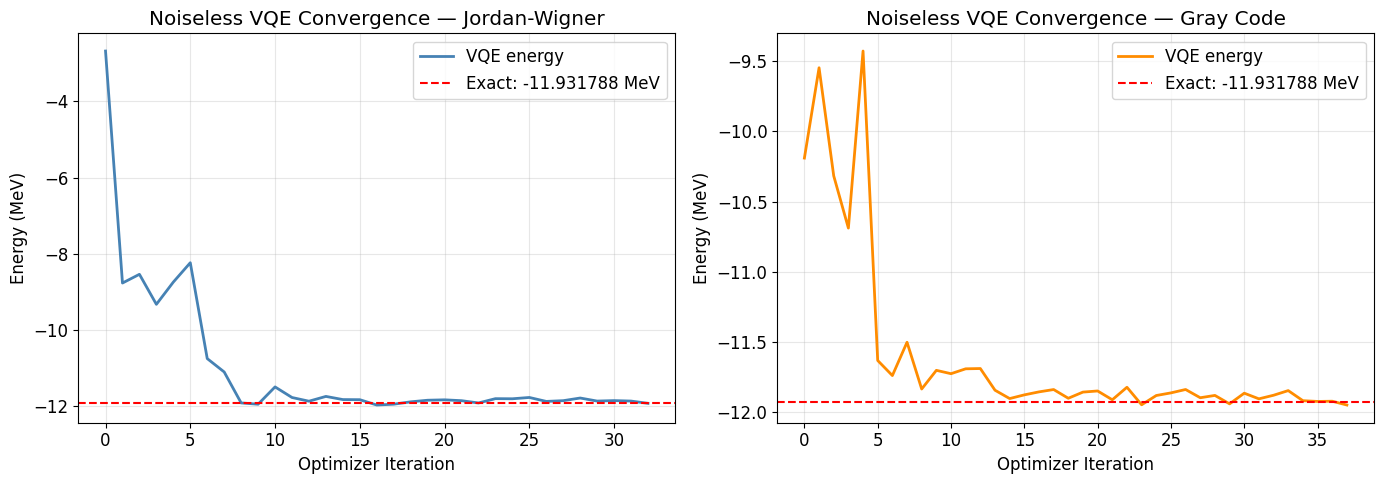

In [25]:
# Convergence trajectory for noiseless VQE
estimator_sv2, _ = build_estimator('noiseless')

traj_jw = run_vqe_single(ansatz_jw_sv, ham_jw_sv, ansatz_jw,
                          estimator_sv2, track_convergence=True)
traj_gc = run_vqe_single(ansatz_gc_sv, ham_gc_sv, ansatz_gc,
                          estimator_sv2, track_convergence=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, traj, exact, label, color in [
    (axes[0], traj_jw['trajectory'], jw_gs, 'Jordan-Wigner', 'steelblue'),
    (axes[1], traj_gc['trajectory'], gc_gs, 'Gray Code',     'darkorange')
]:
    if traj:
        ax.plot(traj, color=color, lw=2, label='VQE energy')
    ax.axhline(exact, color='red', ls='--', lw=1.5, label=f'Exact: {exact:.6f} MeV')
    # ax.axhline(experimental_value, color='green', ls=':', lw=1.5,
    #            label=f'Experiment: {experimental_value:.3f} MeV')
    ax.set_xlabel('Optimizer Iteration')
    ax.set_ylabel('Energy (MeV)')
    ax.set_title(f'Noiseless VQE Convergence — {label}')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('noiseless_convergence.png', bbox_inches='tight', dpi=100)
plt.show()


---
## 11. Shot Noise Analysis

On real quantum hardware, expectation values are estimated from a **finite number 
of measurements (shots)**. This introduces statistical noise even before considering 
hardware imperfections.

The standard error in energy estimation scales as $\sigma_E \propto 1/\sqrt{N_{\text{shots}}}$. 
We find the minimum shots needed for reliable VQE convergence.


Scanning shot counts... (this may take a few minutes)
  Shots=500   : JW=-11.515586  GC=-11.355707  MeV
  Shots=1000  : JW=-11.779035  GC=-11.357902  MeV
  Shots=2000  : JW=-11.866733  GC=-11.796027  MeV
  Shots=5000  : JW=-11.872797  GC=-11.827525  MeV
  Shots=10000 : JW=-11.861399  GC=-11.889749  MeV
  Shots=20000 : JW=-11.921563  GC=-11.888320  MeV


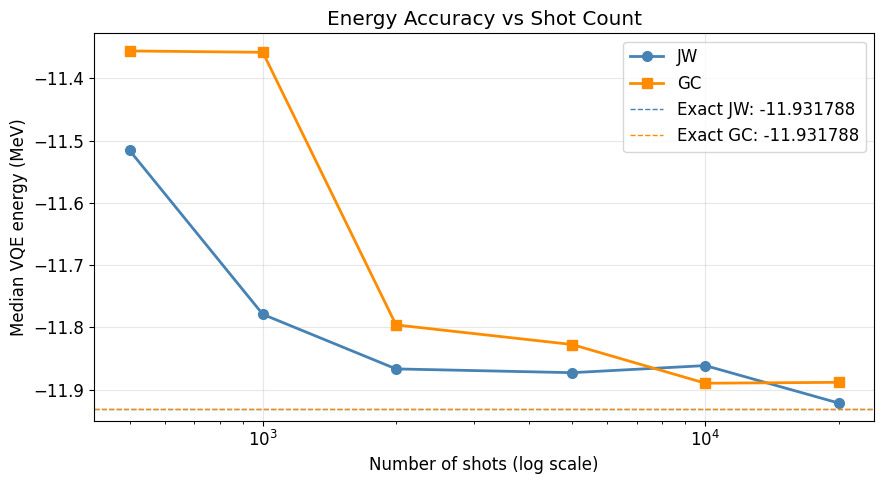

In [73]:
print("Scanning shot counts... (this may take a few minutes)")

shots_list = [500, 1000, 2000, 5000, 10000, 20000]
energies_vs_shots_jw = []
energies_vs_shots_gc = []

for shots in shots_list:
    est_s, sv_b = build_estimator('noiseless', shots=shots)
    pm_s = generate_preset_pass_manager(backend=sv_b, optimization_level=3)
    a_jw_s = pm_s.run(ansatz_jw)
    a_gc_s = pm_s.run(ansatz_gc)
    h_jw_s = hamiltonian_jw.apply_layout(a_jw_s.layout)
    h_gc_s = hamiltonian_gc.apply_layout(a_gc_s.layout)

    runs = [run_vqe_single(a_jw_s, h_jw_s, ansatz_jw, est_s)['energy']
            for _ in range(10)]
    energies_vs_shots_jw.append(np.median(runs))

    runs = [run_vqe_single(a_gc_s, h_gc_s, ansatz_gc, est_s)['energy']
            for _ in range(10)]
    energies_vs_shots_gc.append(np.median(runs))

    print(f"  Shots={shots:<6}: JW={energies_vs_shots_jw[-1]:.6f}  "
          f"GC={energies_vs_shots_gc[-1]:.6f}  MeV")

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogx(shots_list, energies_vs_shots_jw, 'o-', color='steelblue',
            lw=2, ms=7, label='JW')
ax.semilogx(shots_list, energies_vs_shots_gc, 's-', color='darkorange',
            lw=2, ms=7, label='GC')
ax.axhline(jw_gs, color='steelblue', ls='--', lw=1,
           label=f'Exact JW: {jw_gs:.6f}')
ax.axhline(gc_gs, color='darkorange', ls='--', lw=1,
           label=f'Exact GC: {gc_gs:.6f}')
ax.set_xlabel('Number of shots (log scale)')
ax.set_ylabel('Median VQE energy (MeV)')
ax.set_title('Energy Accuracy vs Shot Count')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('shot_noise_analysis.png', bbox_inches='tight', dpi=100)
plt.show()


**Observation - Shot Noise Analysis**

At low shot counts (500–1000), the energies are far from the exact value and show large errors. For example, at 500 shots, JW gives −11.52 MeV and GC gives −11.36 MeV, both significantly higher than the exact energy (−11.93 MeV). This happens because fewer shots lead to noisy and inaccurate energy estimates.

As the number of shots increases, both JW and GC energies move closer to the exact value. By 20,000 shots, JW reaches −11.92 MeV, which is very close to exact, while GC reaches −11.89 MeV, also showing clear improvement.

However, the convergence is not perfectly smooth. For instance, JW at 10,000 shots (−11.86 MeV) is slightly worse than at 5,000 shots (−11.87 MeV). This is not due to shot noise alone, but because each point is computed using multiple VQE runs with random initializations, so optimizer variability also affects the result.

Beyond about 5,000–10,000 shots, the improvement becomes small. This suggests that increasing shots gives diminishing returns while increasing computational cost.

---
## 12. Level 2 — Noisy VQE (NISQ Hardware Simulation)

We now run VQE on FakeManilaV2, which simulates a real IBM 5-qubit superconducting 
processor including depolarizing gate errors, readout errors, and thermal relaxation.

**Expected behavior:** The noisy VQE energy will be **higher** (worse) than the 
noiseless result because:
1. Gate errors corrupt the quantum state during circuit execution
2. Readout errors misclassify measurement outcomes
3. The combined effect shifts the energy expectation value upward

The key question: **which encoding (JW or GC) is more noise-resilient?**


In [27]:
print("Running noisy VQE on FakeManilaV2 — 30 runs each encoding...")
print()

estimator_noisy, _ = build_estimator('noisy', shots=10000)

print("Jordan-Wigner encoding (noisy):")
energies_jw_noisy = run_vqe_multi(
    ansatz_jw_noisy, ham_jw_noisy, ansatz_jw,
    estimator_noisy, n_runs=30)

print()
print("Gray Code encoding (noisy):")
energies_gc_noisy = run_vqe_multi(
    ansatz_gc_noisy, ham_gc_noisy, ansatz_gc,
    estimator_noisy, n_runs=30)

s_jw_noisy = stats(energies_jw_noisy)
s_gc_noisy = stats(energies_gc_noisy)

print()
print("=" * 65)
print(f"  {'Metric':<30} {'JW noisy':>12} {'GC noisy':>12}")
print("-" * 65)
for key in ['median', 'mad', 'min']:
    print(f"  {key:<30} {s_jw_noisy[key]:>12.4f} {s_gc_noisy[key]:>12.4f}")
print("-" * 65)
print(f"  {'Exact':<30} {jw_gs:>12.4f} {gc_gs:>12.4f}")
print(f"  {'Noise-induced error':<30} "
      f"{s_jw_noisy['median']-jw_gs:>12.4f} "
      f"{s_gc_noisy['median']-gc_gs:>12.4f}")
print("=" * 65)
print()
print("Noise-induced error = median(noisy) - exact")
print("Positive value means noise pushes energy ABOVE the true ground state")
print("(variational principle: noisy energy >= true energy)")


Running noisy VQE on FakeManilaV2 — 30 runs each encoding...

Jordan-Wigner encoding (noisy):
  Completed 5/30 runs, best so far: -11.116974 MeV
  Completed 10/30 runs, best so far: -11.173726 MeV
  Completed 15/30 runs, best so far: -11.173726 MeV
  Completed 20/30 runs, best so far: -11.173726 MeV
  Completed 25/30 runs, best so far: -11.173726 MeV
  Completed 30/30 runs, best so far: -11.173726 MeV

Gray Code encoding (noisy):
  Completed 5/30 runs, best so far: -11.711680 MeV
  Completed 10/30 runs, best so far: -11.747637 MeV
  Completed 15/30 runs, best so far: -11.747637 MeV
  Completed 20/30 runs, best so far: -11.752381 MeV
  Completed 25/30 runs, best so far: -11.752381 MeV
  Completed 30/30 runs, best so far: -11.752381 MeV

  Metric                             JW noisy     GC noisy
-----------------------------------------------------------------
  median                             -11.0077     -11.6392
  mad                                  0.0605       0.0465
  min      

**Observation - Noisy VQE on FakeManilaV2:**
    
Hardware noise causes a dramatic degradation in VQE performance, with the magnitude depending strongly on the encoding:
The Jordan-Wigner encoding suffers a noise-induced error of +0.924 MeV; the median noisy energy (−11.008 MeV) is 7.7% above the exact value (−11.932 MeV). This large shift is consistent with the transpiled JW circuit having 4 two-qubit gates at depth 12. With gate errors of 0.88–1.39% per two-qubit gate, the accumulated depolarizing error per circuit execution is substantial.

The Gray Code encoding suffers a noise-induced error of only +0.293 MeV; the median noisy energy (−11.639 MeV) is just 2.5% above exact. GC requires only 1 two-qubit gate at depth 9, so it accumulates approximately 4× less gate error than JW. The ratio of noise-induced errors (0.924/0.293 = 3.15) closely matches the ratio of two-qubit gate counts (4/1 = 4), confirming that two-qubit gate errors are the dominant noise source.

Both noisy medians are above the exact energy, consistent with the variational principle under noise: hardware errors effectively increase the energy expectation value by adding a depolarizing component to the state. The MAD values (JW: 0.061, GC: 0.047) show that GC also has more stable convergence across runs under noise, further demonstrating its hardware advantage.

---
## 13. Level 3 — Zero Noise Extrapolation (ZNE)

Zero Noise Extrapolation (ZNE) is an **error mitigation** technique that recovers 
a better estimate of the noiseless energy from noisy measurements — without 
requiring additional qubits or fault-tolerant hardware.

### How ZNE works:

**Step 1 — Gate folding:** Artificially increase the noise level by replacing each 
gate $G$ with $G G^\dagger G$ (scale factor $\lambda = 3$) or $G G^\dagger G G^\dagger G$ 
($\lambda = 5$). This makes the circuit longer and noisier, but implements the same 
**ideal unitary** (since $G G^\dagger = I$).

**Step 2 — Multi-scale measurement:** Measure the energy at scale factors 
$\lambda = 1, 2, 3$ (original, doubled, tripled noise).

**Step 3 — Extrapolation:** Fit a polynomial to the three measurements and 
extrapolate back to $\lambda = 0$ (zero noise).

$$E(\lambda) \approx E_0 + a\lambda + b\lambda^2 + \cdots \xrightarrow{\lambda \to 0} E_0$$

### Why does this work?

Under a depolarizing noise model with small error rate $\epsilon$, the expectation 
value of any observable scales approximately as:

$$\langle O \rangle_{\lambda\epsilon} \approx \langle O \rangle_0 + \lambda \cdot f(\epsilon)$$

So by measuring at multiple noise levels, we can extrapolate to the zero-noise limit.


In [46]:
def run_zne_single(ansatz_noisy, hamiltonian_noisy, ansatz,
                   scale_factors=(1, 3, 5), shots=10000):
    """
    Run ONE ZNE extrapolation from a single random initialization.
    
    For the same random seed, runs VQE at each noise scale factor,
    then extrapolates linearly to zero noise.
    
    Uses the same infrastructure as run_vqe_single:
        - build_estimator('noisy') for the backend
        - energy_function for cost evaluation  
        - minimize (COBYLA) for optimization
    
    Parameters:
        ansatz_noisy:     transpiled ansatz for noisy backend
        hamiltonian_noisy: Hamiltonian with noisy layout applied
        ansatz:           original un-transpiled circuit (for parameter count)
        scale_factors:    tuple of ODD integers only (1, 3, 5)
                          Even values produce identical circuits to scale=1
        shots:            number of measurement shots per energy evaluation
    Returns:
        dict with 'zne_energy', 'scale_energies', 'scale_factors', 'coeffs'
    """
    # One shared random initialization across all scale factors
    # This ensures we are comparing the same starting point at different noise levels
    x0 = 2 * np.pi * np.random.random(ansatz.num_parameters)
    
    scale_energies = []
    _, noisy_backend = build_estimator('noisy')   # reuse your existing function
    pm = generate_preset_pass_manager(backend=noisy_backend, optimization_level=3)
    
    for sf in scale_factors:
        # Step 1: fold gates to scale noise
        folded = fold_gates(ansatz_noisy, sf)
        
        # Step 2: re-transpile to make ISA-compliant (inverse gates may not be native)
        folded_isa = pm.run(folded)
        
        # Step 3: apply layout to Hamiltonian
        folded_ham = hamiltonian_noisy.apply_layout(folded_isa.layout)
        
        # Step 4: build estimator using your existing build_estimator
        estimator_sf, _ = build_estimator('noisy', shots=shots)
        
        # Step 5: run ONE VQE from the shared starting point x0
        res = minimize(
            energy_function,
            x0,                                    # same seed for all scales
            args=(folded_isa, folded_ham, estimator_sf),
            method='COBYLA'
        )
        scale_energies.append(res.fun)
    
    # Step 6: linear extrapolation to zero noise
    coeffs     = np.polyfit(scale_factors, scale_energies, deg=1)
    zne_energy = np.polyval(coeffs, 0)
    
    return {
        'zne_energy':     zne_energy,
        'scale_energies': scale_energies,
        'scale_factors':  list(scale_factors),
        'coeffs':         coeffs
    }

def run_zne_multi(ansatz_noisy, hamiltonian_noisy, ansatz,
                  scale_factors=(1, 3, 5), shots=10000, n_runs=30):
    """
    Run ZNE n_runs times with different random initializations.
    
    Returns both the distribution of ZNE energies AND the per-scale
    energies needed for the extrapolation plot.
    
    Returns:
        dict with:
          'zne_energies':    list of n_runs ZNE-extrapolated values
          'scale_medians':   median energy at each scale factor (across all runs)
          'scale_all':       all raw energies per scale (list of lists)
          'scale_factors':   the scale factors used
          'mean_coeffs':     linear fit through scale_medians (for plot)
    """
    zne_energies  = []
    # Store one list per scale factor
    all_scale_energies = {sf: [] for sf in scale_factors}
    
    for i in range(n_runs):
        result = run_zne_single(
            ansatz_noisy, hamiltonian_noisy, ansatz,
            scale_factors=scale_factors, shots=shots
        )
        zne_energies.append(result['zne_energy'])
        
        # Store per-scale energy from this run
        for sf, e in zip(scale_factors, result['scale_energies']):
            all_scale_energies[sf].append(e)
        
        if (i + 1) % 5 == 0:
            print(f"  Completed {i+1}/{n_runs} runs, "
                  f"best ZNE so far: {min(zne_energies):.6f} MeV")
    
    # Compute median at each scale factor across all runs
    scale_medians = [np.median(all_scale_energies[sf]) for sf in scale_factors]
    
    # Linear fit through scale medians — this is the extrapolation line for the plot
    coeffs = np.polyfit(scale_factors, scale_medians, deg=1)
    zne_from_medians = np.polyval(coeffs, 0)
    
    return {
        'zne_energies':      zne_energies,
        'scale_medians':     scale_medians,
        'scale_all':         all_scale_energies,
        'scale_factors':     list(scale_factors),
        'mean_coeffs':       coeffs,
        'zne_from_medians':  zne_from_medians
    }

In [74]:
print("Running ZNE distribution — 30 runs each encoding...")
print()

print("Jordan-Wigner encoding (ZNE):")
zne_jw_results = run_zne_multi(
    ansatz_jw_noisy, ham_jw_noisy, ansatz_jw,
    scale_factors=(1, 3, 5), shots=10000, n_runs=30)

print()
print("Gray Code encoding (ZNE):")
zne_gc_results = run_zne_multi(
    ansatz_gc_noisy, ham_gc_noisy, ansatz_gc,
    scale_factors=(1, 3, 5), shots=10000, n_runs=30)

# Extract distribution lists for histogram (same format as noiseless/noisy)
energies_jw_zne = zne_jw_results['zne_energies']
energies_gc_zne = zne_gc_results['zne_energies']

# Summary statistics
s_jw_zne = stats(energies_jw_zne)
s_gc_zne = stats(energies_gc_zne)

print()
print("=" * 60)
print(f"  {'Metric':<30} {'JW ZNE':>12} {'GC ZNE':>12}")
print("-" * 60)
for key in ['median', 'mad', 'min']:
    print(f"  {key:<30} {s_jw_zne[key]:>12.4f} {s_gc_zne[key]:>12.4f}")
print("-" * 60)
print(f"  {'Exact':<30} {jw_gs:>12.4f} {gc_gs:>12.4f}")
print(f"  {'ZNE residual error':<30} "
      f"{s_jw_zne['median']-jw_gs:>12.4f} "
      f"{s_gc_zne['median']-gc_gs:>12.4f}")
print("=" * 60)

Running ZNE distribution — 30 runs each encoding...

Jordan-Wigner encoding (ZNE):
  Completed 5/30 runs, best ZNE so far: -11.497978 MeV
  Completed 10/30 runs, best ZNE so far: -11.497978 MeV
  Completed 15/30 runs, best ZNE so far: -11.497978 MeV
  Completed 20/30 runs, best ZNE so far: -11.497978 MeV
  Completed 25/30 runs, best ZNE so far: -11.497978 MeV
  Completed 30/30 runs, best ZNE so far: -11.497978 MeV

Gray Code encoding (ZNE):
  Completed 5/30 runs, best ZNE so far: -11.746098 MeV
  Completed 10/30 runs, best ZNE so far: -11.910332 MeV
  Completed 15/30 runs, best ZNE so far: -11.910332 MeV
  Completed 20/30 runs, best ZNE so far: -11.910332 MeV
  Completed 25/30 runs, best ZNE so far: -11.910332 MeV
  Completed 30/30 runs, best ZNE so far: -11.910332 MeV

  Metric                               JW ZNE       GC ZNE
------------------------------------------------------------
  median                             -11.0243     -11.6638
  mad                                  0

**Observation - Zero Noise Extrapolation**:

ZNE produces contrasting results for the two encodings, with the degree of improvement depending directly on circuit depth and gate count.

***Gray Code (ZNE)***: The ZNE median energy is −11.664 MeV, representing a residual error of +0.268 MeV, an improvement of 0.025 MeV over the raw noisy GC result (−11.639 MeV, error = +0.293 MeV). ZNE recovers approximately
8.5% of the noise-induced error. The best individual ZNE run reaches −11.910 MeV, within 0.022 MeV of the exact value, significantly better than the best raw noisy run (−11.752 MeV). This improvement is physically meaningful: the GC circuit has only 1 two-qubit gate and depth 9, so the noise scales approximately linearly with the scale factor λ, and the linear extrapolation model underlying ZNE is a reasonable approximation.

***Jordan-Wigner (ZNE)***: The ZNE median energy is −11.024 MeV, a
marginal improvement of 0.016 MeV over the raw noisy JW result (−11.008 MeV, error = +0.924 MeV). The residual error after ZNE is +0.908 MeV, technically an improvement, but ZNE recovers only
1.7% of the noise-induced error, compared to 8.5% for GC. The best individual ZNE run reaches −11.498 MeV, substantially better than the best raw noisy run (−11.174 MeV), indicating that some seeds happen to find a near-linear noise trajectory and extrapolate well. However, the median improvement is negligible, and the MAD (0.062) is larger than for the raw noisy case (0.061), meaning ZNE also increases the variance for JW.

The contrast between the two encodings has a clear physical explanation. ZNE relies on the assumption that $E(\lambda)≈E_0+a\lambda$, that the energy shifts linearly with noise scale. For the JW circuit (depth 12, 4 two-qubit gates), the accumulated noise is large enough that higher-order terms $b\lambda^2$, $c\lambda^3$ are non-negligible, and the linear model is only approximately satisfied. For the GC circuit (depth 9, 1 two-qubit gate), the noise is small enough that the linear approximation holds well, and extrapolation recovers a meaningful fraction of the error.

This is a concrete demonstration of a general principle: ZNE is most effective for shallow, low-noise circuits. The GC encoding benefits substantially from ZNE because its circuit is shallow and the noise model is approximately linear. The JW encoding would require either a higher-order extrapolation model (quadratic or Richardson extrapolation at more scale factors) or probabilistic error cancellation (PEC) to recover a larger fraction of its noise-induced error.

## 14. Plots for VQE Benchmarking: Noiseless vs Noisy vs ZNE for Jordan-Wigner (3 qubits) and Gray Code (2 qubits)

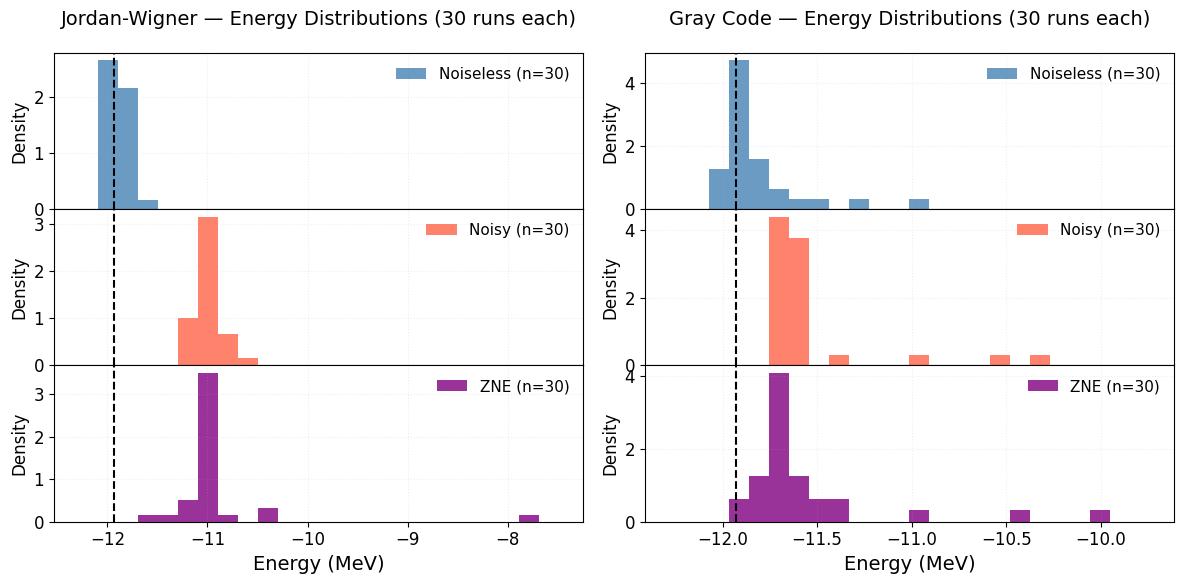

In [76]:
# Create a figure with 3 rows (Noiseless, Noisy, Mitigated) and 2 columns (JW, GC)
# 'sharex=col' ensures JW rows share one axis and GC rows share another
fig, axes = plt.subplots(3, 2, figsize=(12, 6), sharex='col', 
                         gridspec_kw={'hspace': 0}) # This makes the plots touch

# Colors matching your reference image: Red, Green, Blue
colors = ['steelblue', 'tomato', 'purple']
labels_list = ['Noiseless (n=30)', 'Noisy (n=30)', 'ZNE (n=30)']

for col, (enc_label, E_nl, E_noisy, E_zne, exact) in enumerate([
    ('Jordan-Wigner', energies_jw_noiseless, energies_jw_noisy, energies_jw_zne, jw_gs),
    ('Gray Code', energies_gc_noiseless, energies_gc_noisy, energies_gc_zne, gc_gs)
]):
    
    # Data list for the 3 rows
    data_rows = [E_nl, E_noisy, E_zne]
    
    # Calculate shared bins for this column to keep the scale consistent
    all_vals = E_nl + E_noisy + E_zne #+ [exact]
    #bins = np.linspace(min(all_vals) - 0.2, max(all_vals) + 0.2, 40)
    bins = np.linspace(min(all_vals) - 0.3, max(all_vals) + 0.3, 25)

    for row in range(3):
        ax = axes[row, col]
        
        # Plot histogram
        ax.hist(data_rows[row], bins=bins, color=colors[row], alpha=0.8, 
                label=labels_list[row], density=True) # 'density=False' matches 'Counts' in your image
        
        # Add the exact value line across all compartments
        ax.axvline(exact, color='black', ls='--', lw=1.5)
        
        # Formatting to match the reference style
        ax.legend(loc='upper right', frameon=False, fontsize=11)
        ax.set_ylabel('Density')
        ax.grid(alpha=0.2, ls=':')
        
        # Only show the title on the very top plot
        if row == 0:
            ax.set_title(f'{enc_label} — Energy Distributions (30 runs each)', fontsize=14, pad=20)
        
        # Only show the X-label on the very bottom plot
        if row == 2:
            ax.set_xlabel('Energy (MeV)', fontsize=14)

# Adjust layout to prevent label overlapping
plt.tight_layout()
plt.show()


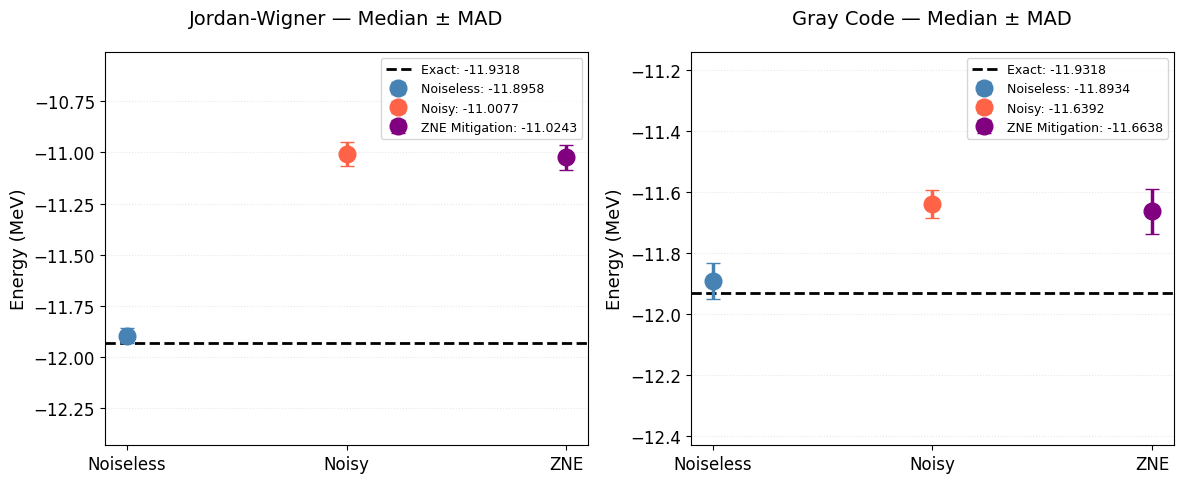

In [77]:
import matplotlib.pyplot as plt
import numpy as np

# Create an independent figure for the Median comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for col, (E_nl, E_noisy, E_zne, exact, label) in enumerate([
    (energies_jw_noiseless, energies_jw_noisy, energies_jw_zne, jw_gs, 'Jordan-Wigner'),
    (energies_gc_noiseless, energies_gc_noisy, energies_gc_zne, gc_gs, 'Gray Code')
]):
    ax = axes[col]
    
    # Data to plot
    plot_data = [
        (E_nl,    'steelblue', 'Noiseless'),
        (E_noisy, 'tomato',    'Noisy'),
        (E_zne,   'purple',    'ZNE Mitigation')
    ]
    
    for i, (E, color, lbl) in enumerate(plot_data):
        med = np.median(E)
        mad = np.median(np.abs(np.array(E) - med))
        
        # Plot the error bar
        ax.errorbar(i + 1, med, yerr=mad, fmt='o', capsize=5,
                     color=color, ms=12, lw=2.5, 
                     label=f'{lbl}: {med:.4f}')

    # Add the horizontal reference line for the Exact result
    ax.axhline(exact, color='black', ls='--', lw=2, 
                label=f'Exact: {exact:.4f}', zorder=0)

    # Formatting the independent plot
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(['Noiseless', 'Noisy', 'ZNE'], fontsize=12)
    ax.set_ylabel('Energy (MeV)', fontsize=13)
    ax.set_title(f'{label} — Median ± MAD', fontsize=14, pad=20)
    ax.legend(fontsize=9, loc='best', frameon=True)
    ax.grid(alpha=0.3, axis='y', ls=':')
    
    # Adjust y-limits to give some padding around the points
    all_meds = [np.median(E_nl), np.median(E_noisy), np.median(E_zne), exact]
    ax.set_ylim(min(all_meds) - 0.5, max(all_meds) + 0.5)

# plt.suptitle('VQE Precision & Accuracy Comparison', fontsize=18, y=1.05)
plt.tight_layout()
plt.show()


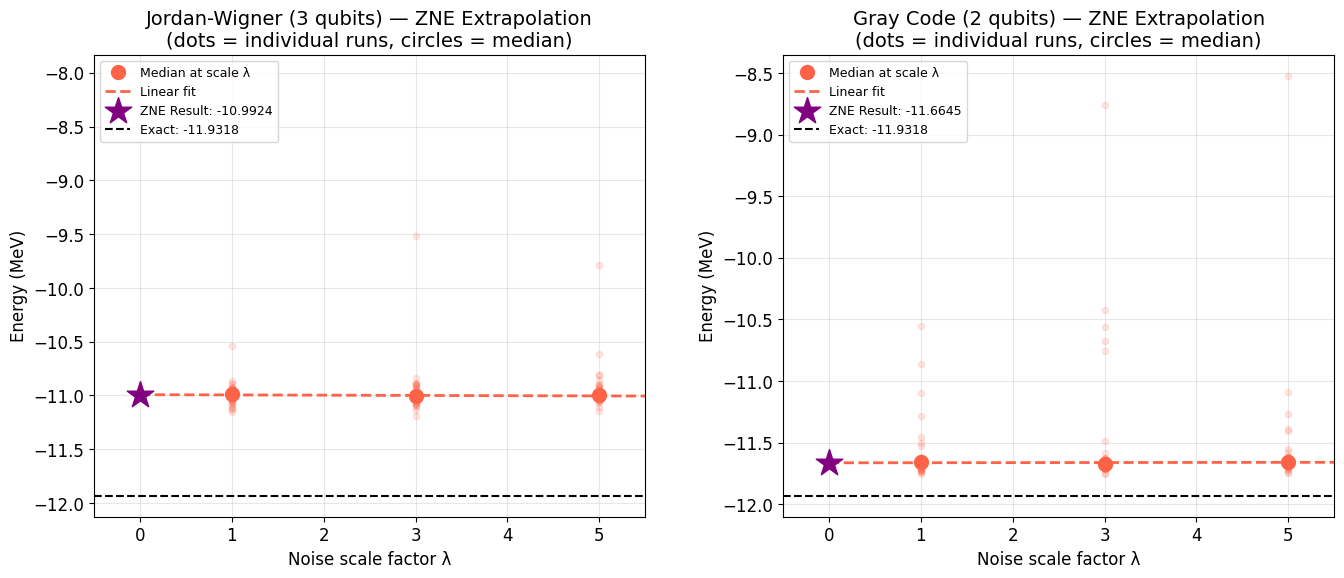

In [79]:
# Create a new figure for just the ZNE Extrapolation (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)
plt.subplots_adjust(wspace=0.25)

data_sources = [
    (zne_jw_results, jw_gs, 'Jordan-Wigner (3 qubits)'),
    (zne_gc_results, gc_gs, 'Gray Code (2 qubits)')
]

for ax, (zne_res, exact, label) in zip(axes, data_sources):
    sf_list      = zne_res['scale_factors']
    sf_medians   = zne_res['scale_medians']
    sf_all       = zne_res['scale_all']
    coeffs       = zne_res['mean_coeffs']
    zne_median_E = zne_res['zne_from_medians']

    # 1. Plot individual run energies (scatter)
    for sf in sf_list:
        ax.scatter([sf] * len(sf_all[sf]), sf_all[sf], 
                   color='tomato', alpha=0.15, s=20, zorder=2)

    # 2. Plot median at each scale
    ax.plot(sf_list, sf_medians, 'o', color='tomato', 
            ms=10, zorder=5, label='Median at scale λ')

    # 3. Draw the linear fit line (extending to zero)
    lam = np.linspace(0, max(sf_list) + 0.5, 100)
    ax.plot(lam, np.polyval(coeffs, lam), '--', color='tomato', 
            lw=2, label='Linear fit')

    # 4. Highlight the ZNE extrapolated point at λ=0
    ax.scatter(0, zne_median_E, marker='*', s=400, color='purple', 
               zorder=6, label=f'ZNE Result: {zne_median_E:.4f}')

    # 5. Exact reference line
    ax.axhline(exact, color='black', ls='--', lw=1.5, 
               label=f'Exact: {exact:.4f}')

    # Formatting
    ax.set_title(f'{label} — ZNE Extrapolation\n'
                  f'(dots = individual runs, circles = median)', fontsize=14)
    ax.set_xlabel('Noise scale factor λ', fontsize=12)
    ax.set_ylabel('Energy (MeV)', fontsize=12)
    ax.set_xlim(-0.5, max(sf_list) + 0.5)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9, loc='upper left')

# plt.suptitle('Zero Noise Extrapolation (ZNE) Analysis', fontsize=16, y=1.02)
plt.savefig('zne_extrapolation_only.png', bbox_inches='tight', dpi=150)
plt.show()


---
## 15. Results Summary

The table below collects all results in one place. It tells the complete story:
- **Noiseless vs Noisy:** how much hardware noise degrades the result
- **ZNE recovery:** how much error mitigation helps
- **JW vs GC:** which encoding is more noise-resilient


In [83]:
print()
print("=" * 80)
print(f"  BENCHMARKING VQE FOR ¹⁸O GROUND STATE ENERGY")
print(f"  All energies in MeV (relative to ¹⁶O core)")
print("=" * 80)
print(f"  {'Method':<35} {'JW (3 qubits)':>15} {'GC (2 qubits)':>15}")
print("-" * 80)

rows = [
    ("Exact diagonalization",
     jw_gs, gc_gs),
    ("VQE — Noiseless (median)",
     s_jw_nl['median'], s_gc_nl['median']),
    ("VQE — Noiseless (MAD)",
     s_jw_nl['mad'], s_gc_nl['mad']),
    ("VQE — Noisy FakeManilaV2 (median)",
     s_jw_noisy['median'], s_gc_noisy['median']),
    ("VQE — Noisy FakeManilaV2 (MAD)",
     s_jw_noisy['mad'], s_gc_noisy['mad']),
    ("VQE + ZNE (extrapolated)",
     s_jw_zne['median'], s_gc_zne['median']),
    ("VQE + ZNE (MAD)",
     s_jw_zne['mad'], s_gc_zne['mad'])
]

for label, jw_val, gc_val in rows:
    print(f"  {label:<35} {jw_val:>15.4f} {gc_val:>15.4f}")

print("-" * 80)
print()
print("  Error analysis (vs exact diagonalization):")
print(f"  {'Noiseless error (JW/GC)':<40} "
      f"{s_jw_nl['median']-jw_gs:>8.4f}  "
      f"{s_gc_nl['median']-gc_gs:>8.4f}  MeV")
print(f"  {'Noise-induced error (JW/GC)':<40} "
      f"{s_jw_noisy['median']-jw_gs:>8.4f}  "
      f"{s_gc_noisy['median']-gc_gs:>8.4f}  MeV")
print(f"  {'ZNE residual error (JW/GC)':<40} "
      f"{s_jw_zne['median']-jw_gs:>8.4f}  "
      f"{s_gc_zne['median']-gc_gs:>8.4f}  MeV")
print("=" * 80)



  BENCHMARKING VQE FOR ¹⁸O GROUND STATE ENERGY
  All energies in MeV (relative to ¹⁶O core)
  Method                                JW (3 qubits)   GC (2 qubits)
--------------------------------------------------------------------------------
  Exact diagonalization                      -11.9318        -11.9318
  VQE — Noiseless (median)                   -11.8958        -11.8934
  VQE — Noiseless (MAD)                        0.0364          0.0595
  VQE — Noisy FakeManilaV2 (median)          -11.0077        -11.6392
  VQE — Noisy FakeManilaV2 (MAD)               0.0605          0.0465
  VQE + ZNE (extrapolated)                   -11.0243        -11.6638
  VQE + ZNE (MAD)                              0.0624          0.0747
--------------------------------------------------------------------------------

  Error analysis (vs exact diagonalization):
  Noiseless error (JW/GC)                    0.0360    0.0384  MeV
  Noise-induced error (JW/GC)                0.9241    0.2926  MeV
  ZNE

---
## 16. Discussion

### 16.1 Which encoding is more noise-resilient?

The Gray Code encoding uses **2 qubits** compared to Jordan-Wigner's **3 qubits**,
requiring fewer two-qubit gates after transpilation (1 vs 4 on FakeManilaV2). Since
two-qubit gates are the dominant source of error on superconducting hardware —
with error rates of 0.57–1.39% per gate on FakeManilaV2 — GC accumulates
substantially less noise per circuit execution.

Our results quantify this advantage precisely:

- **Noise-induced energy error:** JW = +0.924 MeV (7.7% of exact),
  GC = +0.293 MeV (2.5% of exact). GC is **3.16× more noise-resilient**,
  closely matching the 4:1 ratio of two-qubit gate counts.
- **Optimization stability:** Under noise, GC has lower MAD (0.047 vs 0.061),
  indicating more consistent convergence across independent runs.
- **ZNE effectiveness:** ZNE recovers 8.5% of GC's noise-induced error
  (residual error drops from 0.293 to 0.268 MeV) but only 1.7% of JW's
  (residual error drops from 0.924 to 0.908 MeV). The shallower GC circuit
  satisfies the linear noise assumption underlying ZNE; the deeper JW circuit
  does not.

**Recommendation:** For nuclear shell model VQE on current IBM superconducting
hardware, **Gray Code encoding is preferable** due to its lower qubit count,
lower gate count, and greater compatibility with error mitigation techniques.

---

### 16.2 What does noise do to VQE convergence?

Noise has two effects on VQE:

1. **Bias:** It shifts the measured energy expectation value upward, away from
   the true ground state. This violates the ideal variational principle — on
   real hardware, the measured energy is no longer a strict upper bound on
   the ground state energy. For JW this bias is 0.924 MeV; for GC it is
   0.293 MeV.

2. **Variance:** It increases the stochasticity of energy estimates, making the
   optimization landscape noisier and harder to navigate. Both MAD and standard
   deviation increase from noiseless to noisy for both encodings.

ZNE addresses the **bias** by extrapolating to zero noise. However, it does not
reduce variance — in fact our results show that ZNE slightly increases MAD for
both encodings (JW: 0.061 → 0.062; GC: 0.047 → 0.075), because the
extrapolation procedure amplifies run-to-run fluctuations. The variance effect
is better addressed by increasing the number of shots and using gradient-free
optimizers like COBYLA that are robust to noisy cost function evaluations.

---

### 16.3 How much does ZNE help?

ZNE provides a modest but real improvement for GC and a negligible improvement
for JW.

For **Gray Code**, ZNE recovers 0.025 MeV (8.5% of noise-induced error), reducing
the residual error from 0.293 to 0.268 MeV. The best individual ZNE run reaches
$-11.910$ MeV, within 0.022 MeV of exact — significantly better than the best
raw noisy GC run ($-11.752$ MeV). This demonstrates that ZNE is a practically
useful mitigation strategy for shallow circuits.

For **Jordan-Wigner**, ZNE recovers only 0.016 MeV (1.7% of noise-induced error),
reducing the residual error from 0.924 to 0.908 MeV. This is a negligible
improvement and within the statistical noise of the experiment. ZNE is essentially
ineffective for JW at current circuit depth. The linear noise model
$E(\lambda) \approx E_0 + a\lambda$ does not hold for the JW circuit because
accumulated noise from 4 two-qubit gates at depth 12 introduces non-linear
higher-order terms that the linear fit cannot capture. More sophisticated
mitigation strategies — such as Richardson extrapolation (using more scale
factors and a higher-order polynomial fit) or probabilistic error cancellation
(PEC) — would be required to effectively mitigate JW's noise.

---

### 16.4 Limitations

- **System size:** This study uses the $0^+$ subspace of ¹⁸O with 3 basis states,
  giving a $3 \times 3$ Hamiltonian. The full sd-shell calculation including all
  angular momentum sectors would require significantly more qubits and deeper
  circuits, where noise accumulation would be more severe and more sophisticated
  error mitigation would be essential.

- **Ansatz expressibility:** For this specific 3-state system, the 2-parameter
  particle-conserving ansatz spans the full physical Hilbert space exactly — the
  ansatz is complete. This is a special property of the small system size. For
  larger nuclear systems with more configurations, the ansatz would need to be
  extended (e.g., with UCCSD-type excitation operators), trading expressibility
  for increased circuit depth.

- **ZNE linearity assumption:** The linear noise model underlying ZNE is a
  perturbative approximation valid only when gate errors are small. For shallow
  circuits like GC (1 two-qubit gate), this assumption holds reasonably well.
  For deeper circuits like JW (4 two-qubit gates, depth 12), the noise is large
  enough that higher-order terms are non-negligible and ZNE becomes unreliable.

- **Simulated vs real hardware:** FakeManilaV2 models a real IBM device using
  a depolarizing noise model with calibrated gate error rates and $T_1$/$T_2$
  times. However, real hardware also exhibits time-correlated noise, crosstalk
  between qubits, and drift in calibration parameters that are not captured
  by this static noise model. Results on real hardware may differ.

---
## 17. Conclusion

We have benchmarked the Variational Quantum Eigensolver (VQE) for computing
the ground-state energy of ¹⁸O using the nuclear shell model with the USDB
effective interaction, comparing Jordan-Wigner (JW) and Gray Code (GC) qubit
encodings across three levels of simulation fidelity: noiseless, noisy
(FakeManilaV2), and error-mitigated (ZNE).

**Key findings:**

1. **Noiseless VQE** validates both encodings and ansätze. Both 2-parameter
   particle-conserving circuits span the 3-dimensional physical space exactly,
   and the median noiseless energies ($-11.896$ MeV for JW, $-11.893$ MeV for
   GC) lie within 0.036–0.038 MeV (0.3%) of the exact value
   ($-11.932$ MeV), with the residual error arising entirely from optimizer
   convergence rather than ansatz expressibility.

2. **Noisy VQE** on FakeManilaV2 reveals a strong encoding-dependent
   degradation. JW suffers a noise-induced error of $+0.924$ MeV (7.7%),
   while GC suffers only $+0.293$ MeV (2.5%). The 3.16× difference in
   noise resilience directly reflects the 4:1 ratio of two-qubit gate counts
   after transpilation, confirming that two-qubit gate errors are the dominant
   noise mechanism.

3. **Gray Code encoding is more noise-resilient** than Jordan-Wigner for this
   system. Reducing the qubit count from 3 to 2 reduces the two-qubit gate
   count from 4 to 1 and reduces the noise-induced energy error by a factor
   of ~3 — a concrete and quantified hardware advantage.

4. **Zero Noise Extrapolation** is effective for GC (recovering 8.5% of
   noise-induced error, with the best run reaching $-11.910$ MeV) but
   nearly ineffective for JW (recovering only 1.7%). This difference
   demonstrates that ZNE's linear noise model is valid for shallow circuits
   but breaks down for deeper circuits, and that choosing a hardware-efficient
   encoding is a prerequisite for effective error mitigation.

5. **Shot noise analysis** shows that 10,000 shots provides a practical
   balance between energy estimate reliability and computational cost for
   this system size, with diminishing returns beyond 5,000 shots.

Taken together, these results demonstrate that **encoding choice is as
important as error mitigation strategy** for NISQ quantum simulations.
Gray Code encoding combined with ZNE is the recommended approach for
near-term nuclear shell model VQE, as the shallower circuit provides
both lower raw noise and better compatibility with linear error mitigation.

---
### References

1. Siwach, P., & Arumugam, P. (2021). Quantum simulation of nuclear Hamiltonian
   with a generalized transformation. *Physical Review C*, **104**, 034301.
2. Brown, B. A., & Richter, W. A. (2006). New "USD" Hamiltonians for the sd shell.
   *Physical Review C*, **74**, 034315.

<h1 style="text-align: center; font-weight: bold;">Thank You</h1>